# Kode Python Minggu 4 — Data Mining, K-Means, Evaluasi, dan Skor Prioritas

**Proyek:** Smart Economy Kabupaten/Kota Jawa Barat  
**Kelompok:** Kelompok 3 — D4 SIKC 3B  

Notebook ini mereplikasi proses **Minggu 4**: load data siap hasil ETL Minggu 3, analisis deskriptif, standardisasi fitur, evaluasi K-Means, visualisasi PCA, profil cluster, scoring prioritas wilayah, dan penyimpanan output Data Mining.


In [1]:
# ============================================================
# 0. Import library dan konfigurasi path
# ============================================================
from pathlib import Path
import os
import warnings

# Batasi thread numerik agar K-Means stabil dan tidak hang pada beberapa environment notebook.
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

BASE_DIR = Path.cwd()

input_candidates = [
    BASE_DIR / 'data_siap_dw' / 'data_ready_analisis_2024.csv',
    BASE_DIR.parent / 'data_siap_dw' / 'data_ready_analisis_2024.csv',
    BASE_DIR / 'data_ready_analisis_2024.csv',
    Path('/mnt/data/data_siap_dw/data_ready_analisis_2024.csv'),
    Path('/mnt/data/week3_extract/Minggu 3 Kelompok 3 SIKC 3B/data_siap_dw/data_ready_analisis_2024.csv'),
]

INPUT_PATH = next((p for p in input_candidates if p.exists()), None)
if INPUT_PATH is None:
    raise FileNotFoundError(
        'File data_ready_analisis_2024.csv tidak ditemukan. Jalankan notebook Minggu 3 dulu atau letakkan file di folder data_siap_dw.'
    )

OUTPUT_DIR = BASE_DIR / 'output_data_mining'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Input data mining:', INPUT_PATH)
print('Output folder    :', OUTPUT_DIR)

Input data mining: /mnt/data/data_siap_dw/data_ready_analisis_2024.csv
Output folder    : /mnt/data/output_data_mining


## 1. Load Dataset Input Data Mining
Input utama adalah `data_ready_analisis_2024.csv` dengan grain **1 baris = 1 kabupaten/kota tahun 2024**.

In [2]:
# ============================================================
# 1. LOAD DATASET
# ============================================================
df = pd.read_csv(INPUT_PATH)

features = [
    'tpt',
    'persentase_penduduk_miskin',
    'gini_ratio',
    'ipg',
    'rls',
    'hls',
    'pendidikan_indeks_sederhana',
    'kemiskinan_pengangguran_index',
    'gender_pendidikan_index'
]

required_columns = ['nama_wilayah', 'jenis_wilayah', 'tahun'] + features
missing_cols = [c for c in required_columns if c not in df.columns]
if missing_cols:
    raise ValueError(f'Kolom wajib tidak ditemukan: {missing_cols}')

for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Shape dataset:', df.shape)
print('Jumlah wilayah:', df['nama_wilayah'].nunique())
print('Tahun:', sorted(df['tahun'].dropna().unique().tolist()))
display(df.head())

audit_missing = df[features].isna().sum().reset_index()
audit_missing.columns = ['fitur_model', 'jumlah_missing']
display(audit_missing)

Shape dataset: (27, 12)
Jumlah wilayah: 27
Tahun: [2024]


,nama_wilayah,jenis_wilayah,tahun,tpt,persentase_penduduk_miskin,gini_ratio,ipg,rls,hls,pendidikan_indeks_sederhana,kemiskinan_pengangguran_index,gender_pendidikan_index
0,Kabupaten Bandung,Kabupaten,2024,6.36,6.19,0.364,95.10,9.15,12.74,10.945,12.55,53.0225
1,Kabupaten Bandung Barat,Kabupaten,2024,6.70,10.49,0.400,81.59,8.24,12.00,10.120,17.19,45.8550
2,Kabupaten Bekasi,Kabupaten,2024,8.82,4.80,0.367,90.18,9.76,13.18,11.470,13.62,50.8250
3,Kabupaten Bogor,Kabupaten,2024,7.34,7.05,0.398,90.98,8.39,12.75,10.570,14.39,50.7750
4,Kabupaten Ciamis,Kabupaten,2024,3.37,7.39,0.326,88.29,8.10,14.30,11.200,10.76,49.7450


,fitur_model,jumlah_missing
0,tpt,0
1,persentase_penduduk_miskin,0
2,gini_ratio,0
3,ipg,0
4,rls,0
5,hls,0
6,pendidikan_indeks_sederhana,0
7,kemiskinan_pengangguran_index,0
8,gender_pendidikan_index,0


## 2. Teknik Deskriptif Wajib
Sebelum model dijalankan, fitur utama diringkas untuk melihat kondisi awal data, korelasi, dan perbandingan indikator antarwilayah.

In [3]:
# ============================================================
# 2. TEKNIK DESKRIPTIF
# ============================================================
stats_deskriptif = df[features].describe().T[['mean', '50%', 'min', 'max', 'std']].rename(columns={'50%': 'median'})
stats_deskriptif = stats_deskriptif.round(3)

display(stats_deskriptif)

corr_matrix = df[features].corr().round(3)
display(corr_matrix)

# Top 10 berdasarkan indeks kemiskinan-pengangguran sebagai pembanding awal
eda_top10_rentan = (
    df[['nama_wilayah', 'jenis_wilayah', 'tpt', 'persentase_penduduk_miskin', 'pendidikan_indeks_sederhana', 'kemiskinan_pengangguran_index']]
    .sort_values('kemiskinan_pengangguran_index', ascending=False)
    .head(10)
)
display(eda_top10_rentan)

,mean,median,min,max,std
tpt,6.525,6.730,1.580,8.970,1.707
persentase_penduduk_miskin,8.014,8.410,2.340,11.930,2.649
gini_ratio,0.372,0.367,0.286,0.477,0.046
ipg,90.559,90.980,81.590,96.590,3.772
rls,8.915,8.240,6.950,11.790,1.482
hls,12.919,12.740,12.000,14.300,0.758
pendidikan_indeks_sederhana,10.917,10.570,9.635,12.965,1.075
kemiskinan_pengangguran_index,14.539,14.830,8.610,19.660,2.660
gender_pendidikan_index,50.738,50.775,45.855,54.220,2.271


,tpt,persentase_penduduk_miskin,gini_ratio,ipg,rls,hls,pendidikan_indeks_sederhana,kemiskinan_pengangguran_index,gender_pendidikan_index
tpt,1.000,-0.316,0.593,0.181,0.409,0.152,0.335,0.327,0.229
persentase_penduduk_miskin,-0.316,1.000,-0.434,-0.511,-0.750,-0.713,-0.768,0.793,-0.606
gini_ratio,0.593,-0.434,1.000,0.329,0.716,0.474,0.661,-0.052,0.429
ipg,0.181,-0.511,0.329,1.000,0.642,0.576,0.646,-0.393,0.984
rls,0.409,-0.750,0.716,0.642,1.000,0.824,0.980,-0.485,0.765
hls,0.152,-0.713,0.474,0.576,0.824,1.000,0.921,-0.612,0.697
pendidikan_indeks_sederhana,0.335,-0.768,0.661,0.646,0.980,0.921,1.000,-0.550,0.773
kemiskinan_pengangguran_index,0.327,0.793,-0.052,-0.393,-0.485,-0.612,-0.550,1.000,-0.456
gender_pendidikan_index,0.229,-0.606,0.429,0.984,0.765,0.697,0.773,-0.456,1.000


,nama_wilayah,jenis_wilayah,tpt,persentase_penduduk_miskin,pendidikan_indeks_sederhana,kemiskinan_pengangguran_index
10,Kabupaten Kuningan,Kabupaten,7.78,11.88,10.085,19.66
8,Kabupaten Indramayu,Kabupaten,6.25,11.93,9.635,18.18
6,Kabupaten Cirebon,Kabupaten,6.74,11.00,10.035,17.74
26,Kota Tasikmalaya,Kota,6.49,11.10,11.565,17.59
1,Kabupaten Bandung Barat,Kabupaten,6.70,10.49,10.120,17.19
7,Kabupaten Garut,Kabupaten,6.96,9.68,10.010,16.64
14,Kabupaten Subang,Kabupaten,6.73,9.49,9.785,16.22
5,Kabupaten Cianjur,Kabupaten,5.99,10.14,9.685,16.13
9,Kabupaten Karawang,Kabupaten,8.04,7.86,10.130,15.90
13,Kabupaten Purwakarta,Kabupaten,7.34,8.41,10.195,15.75


## 3. Standardisasi Fitur
K-Means sensitif terhadap skala data, sehingga seluruh fitur numerik distandardisasi sebelum proses clustering.

In [4]:
# ============================================================
# 3. STANDARDISASI FITUR
# ============================================================
model_df = df.dropna(subset=features).copy().reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_df[features])

scaled_df = pd.DataFrame(X_scaled, columns=[f'z_{c}' for c in features])
display(scaled_df.head())
print('Shape matrix model:', X_scaled.shape)

,z_tpt,z_persentase_penduduk_miskin,z_gini_ratio,z_ipg,z_rls,z_hls,z_pendidikan_indeks_sederhana,z_kemiskinan_pengangguran_index,z_gender_pendidikan_index
0,-0.098420,-0.701964,-0.165254,1.226909,0.161721,-0.241089,0.026509,-0.762120,1.025422
1,0.104613,0.952483,0.626011,-2.422900,-0.464026,-1.236328,-0.755599,1.015546,-2.191474
2,1.370580,-1.236774,-0.099315,-0.102259,0.581178,0.350675,0.524215,-0.352185,0.039147
3,0.486791,-0.371075,0.582052,0.113866,-0.360881,-0.227640,-0.328995,-0.057184,0.016706
4,-1.883912,-0.240258,-1.000479,-0.612854,-0.560295,1.856983,0.268252,-1.447901,-0.445576


Shape matrix model: (27, 9)


## 4. Evaluasi Jumlah Cluster
Model diuji pada k=2 sampai k=6 menggunakan **silhouette score** dan **inertia**. K=3 dipakai sebagai konfigurasi akhir karena lebih operasional untuk dashboard stakeholder.

,k,silhouette_score,inertia
0,2,0.375,129.888
1,3,0.303,96.132
2,4,0.305,74.341
3,5,0.273,63.097
4,6,0.237,54.469


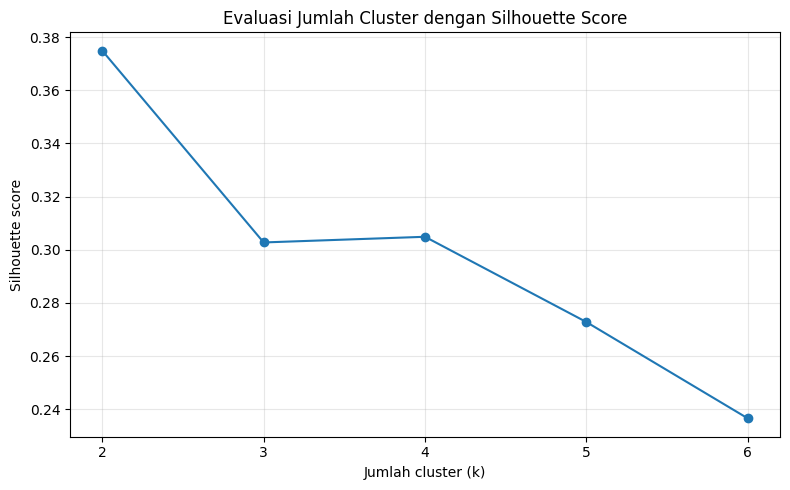

In [5]:
# ============================================================
# 4. EVALUASI JUMLAH CLUSTER
# ============================================================
evaluation_rows = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = kmeans.fit_predict(X_scaled)
    evaluation_rows.append({
        'k': k,
        'silhouette_score': silhouette_score(X_scaled, labels),
        'inertia': kmeans.inertia_
    })

week4_evaluasi_model_kmeans = pd.DataFrame(evaluation_rows)
display(week4_evaluasi_model_kmeans.round(3))

plt.figure(figsize=(8, 5))
plt.plot(week4_evaluasi_model_kmeans['k'], week4_evaluasi_model_kmeans['silhouette_score'], marker='o')
plt.xticks(week4_evaluasi_model_kmeans['k'])
plt.xlabel('Jumlah cluster (k)')
plt.ylabel('Silhouette score')
plt.title('Evaluasi Jumlah Cluster dengan Silhouette Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_silhouette_score.png', dpi=200)
plt.show()

## 5. Model Utama — K-Means Clustering K=3
K=3 digunakan untuk menghasilkan segmentasi wilayah yang lebih mudah dibaca dalam konteks BI: prioritas intervensi, stabil/menengah, dan urban produktif namun tidak merata.

In [6]:
# ============================================================
# 5. MODEL UTAMA K-MEANS K=3
# ============================================================
FINAL_K = 3
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=30)
model_df['cluster_id_model'] = kmeans_final.fit_predict(X_scaled)

# PCA hanya untuk visualisasi 2D, bukan untuk mengganti fitur model utama
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)
model_df['pca1'] = pca_components[:, 0]
model_df['pca2'] = pca_components[:, 1]

print('Silhouette score k=3:', round(silhouette_score(X_scaled, model_df['cluster_id_model']), 3))
print('Inertia k=3:', round(kmeans_final.inertia_, 3))
print('Explained variance PCA:', np.round(pca.explained_variance_ratio_, 3))
display(model_df[['nama_wilayah', 'jenis_wilayah', 'cluster_id_model', 'pca1', 'pca2']].head())

Silhouette score k=3: 0.303
Inertia k=3: 96.132
Explained variance PCA: [0.622 0.183]


,nama_wilayah,jenis_wilayah,cluster_id_model,pca1,pca2
0,Kabupaten Bandung,Kabupaten,2,1.150087,-0.757216
1,Kabupaten Bandung Barat,Kabupaten,1,-2.966611,1.425753
2,Kabupaten Bekasi,Kabupaten,0,1.270695,0.538402
3,Kabupaten Bogor,Kabupaten,2,0.058273,0.474193
4,Kabupaten Ciamis,Kabupaten,2,0.118122,-2.732682


## 6. Skor Prioritas Wilayah
Skor prioritas dibuat sebagai pendukung keputusan. Indikator risiko dinaikkan jika TPT, kemiskinan, gini, dan indeks kerentanan tinggi; serta jika pendidikan dan IPG lebih rendah.

In [7]:
# ============================================================
# 6. SKOR PRIORITAS WILAYAH
# ============================================================
def minmax(series):
    series = pd.to_numeric(series, errors='coerce')
    min_value, max_value = series.min(), series.max()
    if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - min_value) / (max_value - min_value)

week4_bobot_skor_prioritas = pd.DataFrame([
    ['norm_tpt', 0.20, 'TPT tinggi = prioritas lebih tinggi'],
    ['norm_kemiskinan', 0.25, 'Kemiskinan tinggi = prioritas lebih tinggi'],
    ['norm_gini', 0.10, 'Ketimpangan tinggi = prioritas lebih tinggi'],
    ['norm_low_edu', 0.20, 'Pendidikan lebih rendah = prioritas lebih tinggi'],
    ['norm_low_ipg', 0.10, 'IPG lebih rendah = prioritas lebih tinggi'],
    ['norm_rentan', 0.15, 'Gabungan TPT+kemiskinan tinggi = prioritas lebih tinggi'],
], columns=['indikator', 'bobot', 'makna_prioritas'])

model_df['norm_tpt'] = minmax(model_df['tpt'])
model_df['norm_kemiskinan'] = minmax(model_df['persentase_penduduk_miskin'])
model_df['norm_gini'] = minmax(model_df['gini_ratio'])
model_df['norm_low_edu'] = 1 - minmax(model_df['pendidikan_indeks_sederhana'])
model_df['norm_low_ipg'] = 1 - minmax(model_df['ipg'])
model_df['norm_rentan'] = minmax(model_df['kemiskinan_pengangguran_index'])

weights = dict(zip(week4_bobot_skor_prioritas['indikator'], week4_bobot_skor_prioritas['bobot']))
model_df['priority_score'] = (
    model_df['norm_tpt'] * weights['norm_tpt'] +
    model_df['norm_kemiskinan'] * weights['norm_kemiskinan'] +
    model_df['norm_gini'] * weights['norm_gini'] +
    model_df['norm_low_edu'] * weights['norm_low_edu'] +
    model_df['norm_low_ipg'] * weights['norm_low_ipg'] +
    model_df['norm_rentan'] * weights['norm_rentan']
)

# Label cluster ditentukan berdasarkan karakter rata-rata cluster
cluster_summary_for_label = model_df.groupby('cluster_id_model').agg(
    priority_score_mean=('priority_score', 'mean'),
    pendidikan_mean=('pendidikan_indeks_sederhana', 'mean'),
    tpt_mean=('tpt', 'mean'),
    gini_mean=('gini_ratio', 'mean'),
    miskin_mean=('persentase_penduduk_miskin', 'mean')
)

priority_cluster = cluster_summary_for_label['priority_score_mean'].idxmax()
urban_cluster = cluster_summary_for_label.drop(index=priority_cluster)['pendidikan_mean'].idxmax()
stable_cluster = [c for c in cluster_summary_for_label.index if c not in [priority_cluster, urban_cluster]][0]

label_map = {
    priority_cluster: 'Prioritas Intervensi Sosial-Ekonomi',
    urban_cluster: 'Wilayah Urban Produktif namun Tidak Merata',
    stable_cluster: 'Relatif Stabil / Menengah',
}
model_df['cluster_label'] = model_df['cluster_id_model'].map(label_map)

week4_hasil_data_mining_cluster_priority = (
    model_df
    .sort_values('priority_score', ascending=False)
    .reset_index(drop=True)
)
week4_hasil_data_mining_cluster_priority['priority_rank'] = range(1, len(week4_hasil_data_mining_cluster_priority) + 1)

output_cols = [
    'priority_rank', 'nama_wilayah', 'jenis_wilayah', 'cluster_id_model', 'cluster_label', 'priority_score',
    'tpt', 'persentase_penduduk_miskin', 'gini_ratio', 'ipg', 'rls', 'hls',
    'pendidikan_indeks_sederhana', 'kemiskinan_pengangguran_index', 'gender_pendidikan_index',
    'pca1', 'pca2'
]
week4_hasil_data_mining_cluster_priority = week4_hasil_data_mining_cluster_priority[output_cols]

display(week4_bobot_skor_prioritas)
display(week4_hasil_data_mining_cluster_priority.head(10))

,indikator,bobot,makna_prioritas
0,norm_tpt,0.20,TPT tinggi = prioritas lebih tinggi
1,norm_kemiskinan,0.25,Kemiskinan tinggi = prioritas lebih tinggi
2,norm_gini,0.10,Ketimpangan tinggi = prioritas lebih tinggi
3,norm_low_edu,0.20,Pendidikan lebih rendah = prioritas lebih tinggi
4,norm_low_ipg,0.10,IPG lebih rendah = prioritas lebih tinggi
5,norm_rentan,0.15,Gabungan TPT+kemiskinan tinggi = prioritas leb...


,priority_rank,nama_wilayah,jenis_wilayah,cluster_id_model,cluster_label,priority_score,tpt,persentase_penduduk_miskin,gini_ratio,ipg,rls,hls,pendidikan_indeks_sederhana,kemiskinan_pengangguran_index,gender_pendidikan_index,pca1,pca2
0,1,Kabupaten Kuningan,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.840186,7.78,11.88,0.369,88.00,7.90,12.27,10.085,19.66,49.0425,-2.374068,1.846002
1,2,Kabupaten Bandung Barat,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.798054,6.70,10.49,0.400,81.59,8.24,12.00,10.120,17.19,45.8550,-2.966611,1.425753
2,3,Kabupaten Cirebon,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.785790,6.74,11.00,0.374,85.43,7.65,12.42,10.035,17.74,47.7325,-2.581419,1.079438
3,4,Kabupaten Indramayu,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.762168,6.25,11.93,0.306,89.78,6.95,12.32,9.635,18.18,49.7075,-2.894984,0.153845
4,5,Kabupaten Garut,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.725658,6.96,9.68,0.324,84.24,7.85,12.17,10.010,16.64,47.1250,-2.856330,0.455848
5,6,Kabupaten Cianjur,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.718124,5.99,10.14,0.338,86.22,7.33,12.04,9.685,16.13,47.9525,-2.895876,0.043684
6,7,Kabupaten Purwakarta,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.693586,7.34,8.41,0.398,87.96,8.14,12.25,10.195,15.75,49.0775,-1.274097,0.987523
7,8,Kabupaten Subang,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.667731,6.73,9.49,0.320,92.11,7.46,12.11,9.785,16.22,50.9475,-1.735365,-0.057563
8,9,Kabupaten Karawang,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.665814,8.04,7.86,0.376,91.98,8.05,12.21,10.130,15.90,51.0550,-0.673060,0.908592
9,10,Kabupaten Majalengka,Kabupaten,1,Prioritas Intervensi Sosial-Ekonomi,0.648349,4.01,10.82,0.354,87.98,7.53,12.27,9.900,14.83,48.9400,-2.370206,-0.887740


## 7. Profil Cluster
Profil cluster merangkum rata-rata, nilai minimum, dan maksimum indikator utama untuk interpretasi hasil model.

In [8]:
# ============================================================
# 7. PROFIL CLUSTER
# ============================================================
profile_features = [
    'tpt', 'persentase_penduduk_miskin', 'gini_ratio', 'ipg', 'rls', 'hls',
    'pendidikan_indeks_sederhana', 'kemiskinan_pengangguran_index', 'gender_pendidikan_index', 'priority_score'
]

week4_profil_cluster = (
    model_df
    .groupby(['cluster_id_model', 'cluster_label'])[profile_features]
    .agg(['mean', 'min', 'max'])
)
week4_profil_cluster.columns = [f'{col}_{stat}' for col, stat in week4_profil_cluster.columns]
week4_profil_cluster = week4_profil_cluster.reset_index().round(3)

display(week4_profil_cluster)

anggota_cluster = (
    model_df
    .groupby('cluster_label')['nama_wilayah']
    .apply(lambda x: '; '.join(sorted(x)))
    .reset_index(name='anggota_wilayah')
)
display(anggota_cluster)

,cluster_id_model,cluster_label,tpt_mean,tpt_min,tpt_max,persentase_penduduk_miskin_mean,persentase_penduduk_miskin_min,persentase_penduduk_miskin_max,gini_ratio_mean,gini_ratio_min,gini_ratio_max,ipg_mean,ipg_min,ipg_max,rls_mean,rls_min,rls_max,hls_mean,hls_min,hls_max,pendidikan_indeks_sederhana_mean,pendidikan_indeks_sederhana_min,pendidikan_indeks_sederhana_max,kemiskinan_pengangguran_index_mean,kemiskinan_pengangguran_index_min,kemiskinan_pengangguran_index_max,gender_pendidikan_index_mean,gender_pendidikan_index_min,gender_pendidikan_index_max,priority_score_mean,priority_score_min,priority_score_max
0,0,Wilayah Urban Produktif namun Tidak Merata,7.755,6.27,8.97,5.270,2.34,9.02,0.422,0.367,0.477,93.631,90.18,96.59,10.919,9.76,11.79,13.729,13.17,14.25,12.324,11.470,12.965,13.025,8.61,15.54,52.978,50.825,54.220,0.433,0.208,0.563
1,1,Prioritas Intervensi Sosial-Ekonomi,6.449,3.74,8.04,9.900,6.87,11.93,0.355,0.306,0.400,87.692,81.59,92.11,7.701,6.95,8.24,12.258,12.00,12.64,9.979,9.635,10.305,16.349,13.97,19.66,48.836,45.855,51.055,0.709,0.597,0.840
2,2,Relatif Stabil / Menengah,5.249,1.58,7.34,7.919,5.85,11.10,0.341,0.286,0.398,91.960,88.29,96.22,8.706,8.10,9.63,13.129,12.31,14.30,10.917,10.205,11.565,13.167,10.33,17.59,51.439,49.745,53.550,0.489,0.392,0.630


,cluster_label,anggota_wilayah
0,Prioritas Intervensi Sosial-Ekonomi,Kabupaten Bandung Barat; Kabupaten Cianjur; Ka...
1,Relatif Stabil / Menengah,Kabupaten Bandung; Kabupaten Bogor; Kabupaten ...
2,Wilayah Urban Produktif namun Tidak Merata,Kabupaten Bekasi; Kota Bandung; Kota Bekasi; K...


## 8. Visualisasi Hasil Data Mining
Visualisasi disiapkan untuk laporan, dashboard, dan lampiran implementasi teknis.

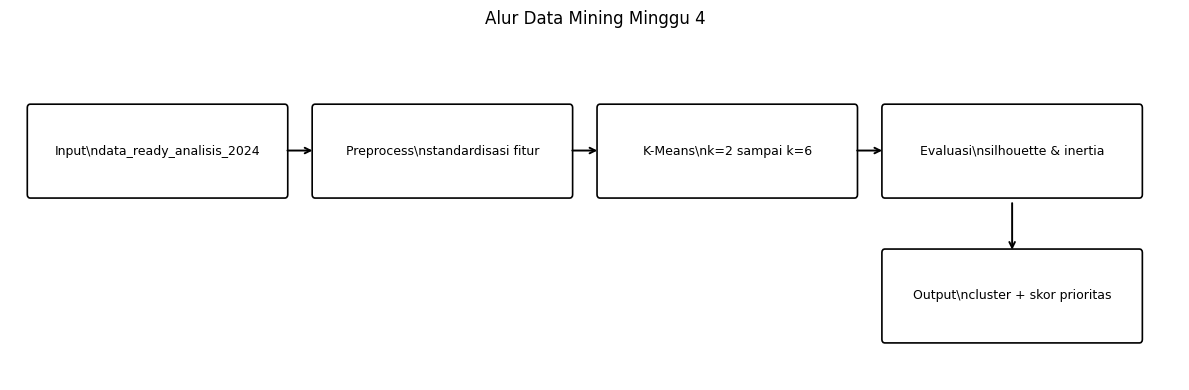

In [9]:
# ============================================================
# 8A. Alur Data Mining
# ============================================================
from matplotlib.patches import FancyBboxPatch

def draw_box(ax, xy, text, width=2.5, height=0.75):
    x, y = xy
    box = FancyBboxPatch((x, y), width, height, boxstyle='round,pad=0.03', linewidth=1.2, facecolor='white')
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=9)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
items = [
    ((0.2, 1.6), 'Input\\ndata_ready_analisis_2024'),
    ((3.0, 1.6), 'Preprocess\\nstandardisasi fitur'),
    ((5.8, 1.6), 'K-Means\\nk=2 sampai k=6'),
    ((8.6, 1.6), 'Evaluasi\\nsilhouette & inertia'),
    ((8.6, 0.35), 'Output\\ncluster + skor prioritas'),
]
for xy, text in items:
    draw_box(ax, xy, text)
for start, end in [((2.7,1.98),(3.0,1.98)), ((5.5,1.98),(5.8,1.98)), ((8.3,1.98),(8.6,1.98)), ((9.85,1.55),(9.85,1.1))]:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', linewidth=1.4))
ax.set_xlim(0, 11.5)
ax.set_ylim(0, 3)
plt.title('Alur Data Mining Minggu 4')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig0_alur_data_mining.png', dpi=200)
plt.show()

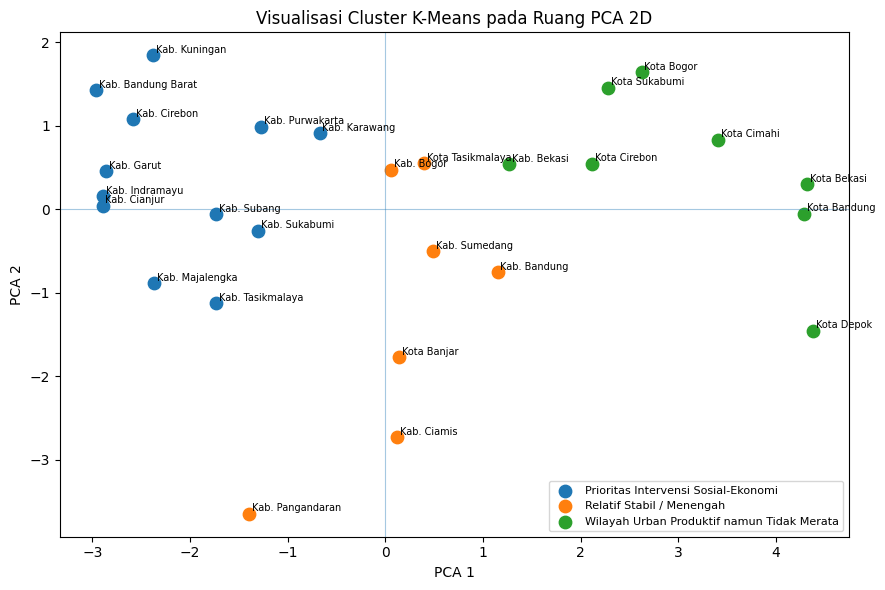

In [10]:
# ============================================================
# 8B. Visualisasi cluster PCA 2D
# ============================================================
plt.figure(figsize=(9, 6))
for label, group in model_df.groupby('cluster_label'):
    plt.scatter(group['pca1'], group['pca2'], label=label, s=80)
    for _, row in group.iterrows():
        plt.text(row['pca1'] + 0.03, row['pca2'] + 0.03, row['nama_wilayah'].replace('Kabupaten ', 'Kab. '), fontsize=7)
plt.axhline(0, linewidth=0.8, alpha=0.4)
plt.axvline(0, linewidth=0.8, alpha=0.4)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualisasi Cluster K-Means pada Ruang PCA 2D')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_visualisasi_cluster_pca.png', dpi=200)
plt.show()

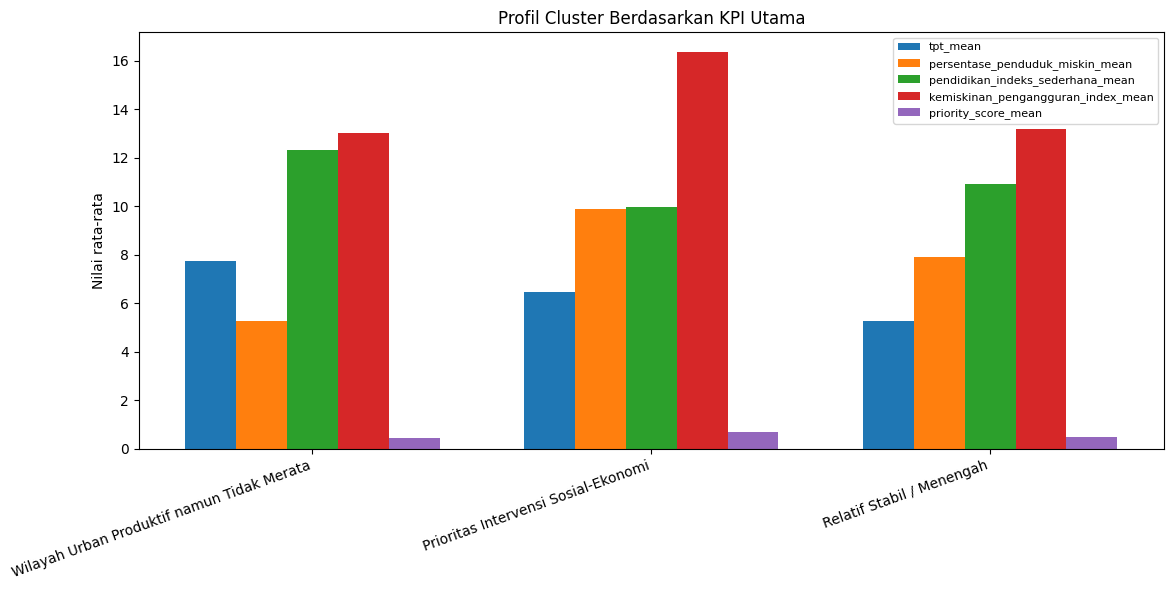

In [11]:
# ============================================================
# 8C. Profil cluster berdasarkan KPI utama
# ============================================================
profile_plot = week4_profil_cluster[[
    'cluster_label', 'tpt_mean', 'persentase_penduduk_miskin_mean',
    'pendidikan_indeks_sederhana_mean', 'kemiskinan_pengangguran_index_mean', 'priority_score_mean'
]].copy()

x = np.arange(len(profile_plot))
width = 0.15
plt.figure(figsize=(12, 6))
for idx, col in enumerate(['tpt_mean', 'persentase_penduduk_miskin_mean', 'pendidikan_indeks_sederhana_mean', 'kemiskinan_pengangguran_index_mean', 'priority_score_mean']):
    plt.bar(x + (idx - 2) * width, profile_plot[col], width=width, label=col)
plt.xticks(x, profile_plot['cluster_label'], rotation=20, ha='right')
plt.ylabel('Nilai rata-rata')
plt.title('Profil Cluster Berdasarkan KPI Utama')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_profil_cluster.png', dpi=200)
plt.show()

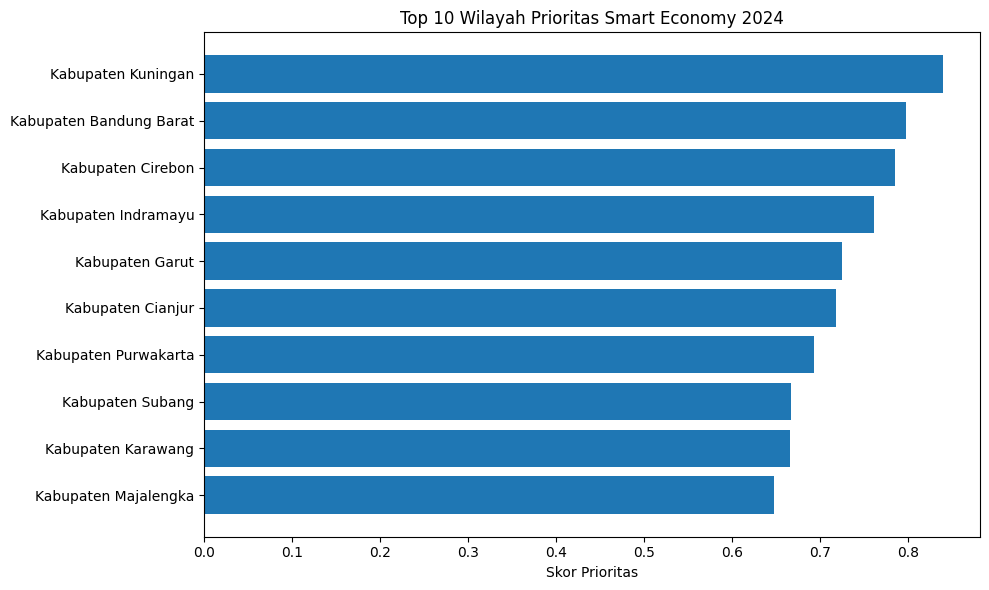

In [12]:
# ============================================================
# 8D. Top 10 wilayah prioritas
# ============================================================
top10 = week4_hasil_data_mining_cluster_priority.head(10).sort_values('priority_score', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top10['nama_wilayah'], top10['priority_score'])
plt.xlabel('Skor Prioritas')
plt.title('Top 10 Wilayah Prioritas Smart Economy 2024')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_top10_prioritas.png', dpi=200)
plt.show()

## 9. Simpan Output Data Mining
Output disimpan sebagai CSV dan PNG agar siap dipakai untuk laporan Minggu 4 dan dashboard Minggu 5.

In [13]:
# ============================================================
# 9. LOAD OUTPUT DATA MINING
# ============================================================
week4_hasil_data_mining_cluster_priority.to_csv(OUTPUT_DIR / 'week4_hasil_data_mining_cluster_priority.csv', index=False)
week4_profil_cluster.to_csv(OUTPUT_DIR / 'week4_profil_cluster.csv', index=False)
week4_evaluasi_model_kmeans.to_csv(OUTPUT_DIR / 'week4_evaluasi_model_kmeans.csv', index=False)
week4_bobot_skor_prioritas.to_csv(OUTPUT_DIR / 'week4_bobot_skor_prioritas.csv', index=False)

print('Output berhasil disimpan di:', OUTPUT_DIR)
for file in sorted(OUTPUT_DIR.glob('*')):
    print('-', file.name)

Output berhasil disimpan di: /mnt/data/output_data_mining
- fig0_alur_data_mining.png
- fig1_silhouette_score.png
- fig2_visualisasi_cluster_pca.png
- fig3_profil_cluster.png
- fig4_top10_prioritas.png
- week4_bobot_skor_prioritas.csv
- week4_evaluasi_model_kmeans.csv
- week4_hasil_data_mining_cluster_priority.csv
- week4_profil_cluster.csv


## 10. Interpretasi Ringkas dan Jawaban Business Question
Bagian ini menghasilkan teks ringkas yang bisa dipakai sebagai draft interpretasi laporan.

In [14]:
# ============================================================
# 10. INTERPRETASI RINGKAS
# ============================================================
jumlah_per_cluster = model_df['cluster_label'].value_counts().reset_index()
jumlah_per_cluster.columns = ['cluster_label', 'jumlah_wilayah']

top_priority = week4_hasil_data_mining_cluster_priority.head(5)[['priority_rank', 'nama_wilayah', 'cluster_label', 'priority_score']]

display(jumlah_per_cluster)
display(top_priority)

print('Interpretasi utama:')
print('- Cluster Prioritas Intervensi Sosial-Ekonomi berisi wilayah dengan skor prioritas rata-rata paling tinggi.')
print('- Cluster Urban Produktif namun Tidak Merata menunjukkan wilayah dengan pendidikan relatif tinggi, tetapi tekanan TPT/gini tetap perlu dipantau.')
print('- Cluster Relatif Stabil/Menengah memiliki tekanan ekonomi lebih rendah dibanding cluster prioritas.')
print('- Top wilayah prioritas dapat dipakai sebagai dasar awal dashboard strategic dan tactical Minggu 5.')

,cluster_label,jumlah_wilayah
0,Prioritas Intervensi Sosial-Ekonomi,12
1,Wilayah Urban Produktif namun Tidak Merata,8
2,Relatif Stabil / Menengah,7


,priority_rank,nama_wilayah,cluster_label,priority_score
0,1,Kabupaten Kuningan,Prioritas Intervensi Sosial-Ekonomi,0.840186
1,2,Kabupaten Bandung Barat,Prioritas Intervensi Sosial-Ekonomi,0.798054
2,3,Kabupaten Cirebon,Prioritas Intervensi Sosial-Ekonomi,0.785790
3,4,Kabupaten Indramayu,Prioritas Intervensi Sosial-Ekonomi,0.762168
4,5,Kabupaten Garut,Prioritas Intervensi Sosial-Ekonomi,0.725658


Interpretasi utama:
- Cluster Prioritas Intervensi Sosial-Ekonomi berisi wilayah dengan skor prioritas rata-rata paling tinggi.
- Cluster Urban Produktif namun Tidak Merata menunjukkan wilayah dengan pendidikan relatif tinggi, tetapi tekanan TPT/gini tetap perlu dipantau.
- Cluster Relatif Stabil/Menengah memiliki tekanan ekonomi lebih rendah dibanding cluster prioritas.
- Top wilayah prioritas dapat dipakai sebagai dasar awal dashboard strategic dan tactical Minggu 5.
